## Load LSST alert file
\
LSST Alert file structured as SNANA-format LSST transient dataset stored as pairs of FITS tables.
- `LSST_CHUNK01_SPLIT001_HEAD.FITS.gz` contains one row per transient including metadata. 
- `LSST_CHUNK01_SPLIT001_PHOT.FITS.gz` contains rows of inividual photometric measurements stored for all objects in HEAD.
- Matching occurs through `PTROBS_MIN` and `PTROBS_MAX` columns, indicating which PHOT rows belong to each object in HEAD.

PHOT fits are separated by a row, BAND="-"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [8]:
from pathlib import Path

lsst_zip = Path("data/LSST_ALERTS.zip")

print("Notebook working directory:")
print(Path.cwd())

print("\nResolved ZIP path:")
print(lsst_zip.resolve())

Notebook working directory:
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/jkt

Resolved ZIP path:
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/jkt/data/LSST_ALERTS.zip

File exists:
True


In [9]:
from zipfile import ZipFile, BadZipFile

try:
    with ZipFile(lsst_zip, "r") as archive:
        file_names = archive.namelist()

    print(f"Number of entries: {len(file_names)}")
    print(*file_names[:30], sep="\n")

except FileNotFoundError:
    print(f"File not found: {lsst_zip.resolve()}")
except BadZipFile:
    print("The file exists but is not a valid ZIP archive.")

Number of entries: 67
LSST_ALERTS/
LSST_ALERTS/LSST/
LSST_ALERTS/TABLE.GARBAGE
LSST_ALERTS/TEXT_archive/
LSST_ALERTS/SUBMIT.INFO
LSST_ALERTS/.DS_Store
__MACOSX/LSST_ALERTS/._.DS_Store
LSST_ALERTS/MERGE.LOG
LSST_ALERTS/TABLE.SNIDALL
LSST_ALERTS/SCRIPTS_MKDATA.tar.gz
LSST_ALERTS/LSST_CHUNK01/
LSST_ALERTS/ALL.DONE
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT010_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT005_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT002_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT007_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT003_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT004_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT006_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST.README
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT009_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT008_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST.IGNORE
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT008_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT009_PHOT.FITS.gz
LSST_

In [10]:
from zipfile import ZipFile

with ZipFile(lsst_zip, "r") as archive:
    readme_name = "LSST_ALERTS/LSST/LSST.README"
    readme_text = archive.read(readme_name).decode(
        "utf-8",
        errors="replace"
    )

print(readme_text[:5000])

DOCUMENTATION: 
  PURPOSE:                   transient lightcurve data files for analysis 
  SOURCE_LSST_FASTDB:        True 
  SURVEY:                    LSST 
  FORMAT:                    FITS 
  USERNAME:                  kessler 
  PHOTFLAG_DETECT:           1 
  # 
  # [___]  @![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]
  PHOTFLAG_GARBAGE:          64 
  NEVT_GARBAGE_ALL:          4472 
  NEVT_GARBAGE_RADEC:        0 
  NEVT_GARBAGE_FLUX_NOTFLOAT:  29 
  NEVT_GARBAGE_FLUX_ZERO:    4443 
  # [___]  @![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]
  # 
  NEVT_PROCESS_ALL:          501084 
  NEVT_WRITE_ALL:            501084 
  NEVT_WRITE_HOST_ZSPEC:     0 
  NEVT_WRITE_HOST_ZPHOT:     0 
  NEVT_WRITE_SPECTRA:        0 
  NEVT_REJECT:               0 
  NEVT_WRITE_BY_FIELD(WFD):  451593 
  NEVT_WRITE_BY_FIELD(DDF):  49491 
  WALLTIME:                  15.97  # minutes 
  ABORT_IF_ZERO:             429 
DOCUMENTATION_END: 



### Data Info:
Includes HEAD and PROT columns as well as size and format 

In [11]:
from io import BytesIO
import gzip
from astropy.io import fits

head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"

with ZipFile(lsst_zip, "r") as archive:
    head_bytes = gzip.decompress(archive.read(head_name))
    phot_bytes = gzip.decompress(archive.read(phot_name))

with fits.open(BytesIO(head_bytes)) as head_hdul:
    head_hdul.info()
    head_data = head_hdul[1].data
    print("\nHEAD columns:")
    print(head_hdul[1].columns.names)
    print("\nNumber of objects:", len(head_data))

with fits.open(BytesIO(phot_bytes)) as phot_hdul:
    phot_hdul.info()
    phot_data = phot_hdul[1].data
    print("\nPHOT columns:")
    print(phot_hdul[1].columns.names)
    print("\nNumber of photometry rows:", len(phot_data))

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      33   (0,)      
  1  Header        1 BinTableHDU    537   51000R x 176C   [40A, 16A, 20A, 1I, 1I, 1D, 1D, 1E, 1I, 1I, 1J, 1J, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1E, 1E, 1E, 1E, 1I, 1I, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   

HEAD columns:
['SNID', 'NAME_IAUC', 'NAME_TRANSIENT', 'FAKE', 'MASK_

In [40]:
# Preliminary important columns:
important_head_columns = [
    "SNID",
    "FAKE", #field missing 
    "SNTYPE", #all are type = "0" currently 
    "RA",
    "DEC",
    "NOBS",
    "PTROBS_MIN",
    "PTROBS_MAX",
    "REDSHIFT_FINAL",
    "HOSTGAL_PHOTOZ",
    "HOSTGAL_SPECZ",
    "PEAKMJD",
    "MJD_TRIGGER",
    "MJD_DETECT_FIRST",
    "MJD_DETECT_LAST",
]

display(head_table[important_head_columns][:10])

SNID,FAKE,SNTYPE,RA,DEC,NOBS,PTROBS_MIN,PTROBS_MAX,REDSHIFT_FINAL,HOSTGAL_PHOTOZ,HOSTGAL_SPECZ,PEAKMJD,MJD_TRIGGER,MJD_DETECT_FIRST,MJD_DETECT_LAST
str40,int16,int32,float64,float64,int32,int32,int32,float32,float32,float32,float32,float32,float32,float32
00000533-33a2-42cf-bfa4-e4951522102f,0,0,282.909373,-18.680916,2,1,2,-999.0,-999.0,-999.0,0.01,0.0,61230.246,61234.29
00001b7e-822c-4030-9b16-cf9cdca02319,0,0,252.565374,-18.918723,2,4,5,-999.0,-999.0,-999.0,0.01,-9.0,61203.223,61234.195
00001dd3-dcbc-436f-99d8-5f310e2212ba,0,0,307.694958,-23.628002,2,7,8,-999.0,-999.0,-999.0,0.01,-9.0,61218.35,61228.36
00004f91-a3cc-4f46-912b-df70ebb4c131,0,0,318.419696,-12.661889,2,10,11,-999.0,-999.0,-999.0,0.01,-9.0,61218.344,61230.293
00005c75-321d-47a7-ad59-9abf192e251b,0,0,260.692795,-16.199554,2,13,14,-999.0,-999.0,-999.0,0.01,-9.0,61203.223,61211.246
00008585-f459-451f-aabe-d8c2eb745ea9,0,0,301.906199,-12.269008,2,16,17,-999.0,-999.0,-999.0,0.01,-9.0,61218.316,61235.258
000088cf-7092-4a37-af20-7bbfc68c08fa,0,0,299.920139,-24.725964,2,19,20,-999.0,-999.0,-999.0,0.01,-9.0,61227.28,61230.285
0000a5e4-bf2c-4e50-ac9b-7ddfc21398ec,0,0,309.96033,-17.141433,2,22,23,-999.0,-999.0,-999.0,0.01,-9.0,61218.32,61228.33
0000b2f4-a428-4210-9449-1d2e2552a3ab,0,0,281.293028,-19.82071,2,25,26,-999.0,-999.0,-999.0,0.01,-9.0,61228.195,61230.246


In [16]:
import numpy as np

def get_lightcurve(head_row, phot_data):
    """Extract one object's PHOT rows from a SNANA FITS pair."""
    ptr_min = int(head_row["PTROBS_MIN"])
    ptr_max = int(head_row["PTROBS_MAX"])
    nobs = int(head_row["NOBS"])

    # SNANA pointers are normally one-indexed and inclusive.
    lc = phot_data[ptr_min - 1:ptr_max]

    if len(lc) != nobs:
        raise ValueError(
            f"SNID {head_row['SNID']}: "
            f"NOBS={nobs}, but pointer range returned {len(lc)} rows."
        )

    return lc

In [17]:

types, counts = np.unique(head_data["SNTYPE"], return_counts=True)

for sn_type, count in zip(types, counts):
    print(sn_type, count)

0 51000


In [18]:
np.unique(head_data["FAKE"], return_counts=True)
np.unique(head_data["SEARCH_TYPE"], return_counts=True)

(array([-9,  0], dtype='>i4'), array([50999,     1]))

In [20]:
np.percentile(
    head_data["NOBS"],
    [0, 1, 5, 25, 50, 75, 90, 95, 99, 100]
)

array([  1.,   1.,   1.,   2.,   2.,   3.,   6.,  13.,  33., 756.])

In [21]:
bands = np.char.strip(
    np.asarray(phot_data["BAND"]).astype(str)
)

np.unique(bands, return_counts=True)

(array(['-', 'g', 'i', 'r', 'u', 'y', 'z'], dtype='<U40'),
 array([51000, 32104, 95154, 42929,  1882,  1465, 49126]))

In [22]:
np.unique(
    phot_data["PHOTFLAG"],
    return_counts=True,
)

(array([ 0,  1, 64, 65], dtype='>i4'), array([ 92312, 173007,   8338,      3]))

In [23]:
for name in [
    "REDSHIFT_HELIO",
    "REDSHIFT_FINAL",
    "HOSTGAL_SPECZ",
    "HOSTGAL_PHOTOZ",
]:
    values = np.asarray(head_data[name], dtype=float)

    print(
        name,
        np.percentile(values, [0, 25, 50, 75, 100])
    )

REDSHIFT_HELIO [-999. -999. -999. -999. -999.]
REDSHIFT_FINAL [-999. -999. -999. -999. -999.]
HOSTGAL_SPECZ [-999. -999. -999. -999. -999.]
HOSTGAL_PHOTOZ [-999. -999. -999. -999. -999.]


In [24]:
print("Sum of NOBS:", np.sum(head_data["NOBS"]))
print("PHOT rows:", len(phot_data))

Sum of NOBS: 222660
PHOT rows: 273660


In [29]:
idx = np.argmax(head_data["NOBS"])
row = head_data[idx]

print("SNID:", row["SNID"])
print("NOBS:", row["NOBS"])
print("SNTYPE:", row["SNTYPE"])

SNID: 00599094-a3e0-4f3e-9f47-4da2dac705fb
NOBS: 756
SNTYPE: 0


In [26]:
start = int(row["PTROBS_MIN"]) - 1
stop = int(row["PTROBS_MAX"])

lc = phot_data[start:stop]

print("Extracted rows:", len(lc))
print("Expected rows:", row["NOBS"])

Extracted rows: 756
Expected rows: 756


In [27]:
for measurement in lc:
    print(
        measurement["MJD"],
        measurement["BAND"],
        measurement["FLUXCAL"],
        measurement["FLUXCALERR"],
        measurement["PHOTFLAG"],
    )

61024.2479 i 2009.6 378.45 1
61024.3213 i 2678.0 325.2 1
61029.3311 g 2510.8 181.9 1
61029.3335 i 2280.0 304.0 1
61032.329 g 1814.4 232.08 1
61041.2234 i 2210.4 426.13 1
61049.315 g 2406.8 356.88 1
61049.3154 g 2378.4 342.47 1
61049.3158 g 2845.0 327.98 1
61049.3162 g 2203.3 324.38 1
61049.3166 g 2086.6 321.4 1
61049.3191 i 2302.1 420.95 1
61049.3199 i 2204.8 429.66 1
61049.3203 i 2600.4 460.88 1
61050.1695 r 2200.8 319.91 1
61050.1699 r 2189.0 297.82 1
61050.1703 r 2181.2 307.67 1
61050.1707 r 1688.2 295.47 1
61050.1711 r 2527.1 268.19 1
61050.1716 r 2465.3 273.54 1
61051.188 g 1826.8 185.33 1
61051.1884 g 1944.1 185.58 1
61051.1887 g 1914.3 191.11 1
61051.1891 g 2001.6 192.42 1
61051.1895 g 2405.8 179.35 1
61051.19 g 2910.9 183.78 1
61053.2523 i 2333.1 335.02 1
61053.2527 i 2617.0 325.57 1
61053.2531 i 2446.9 322.14 1
61053.2535 i 2529.5 305.01 1
61057.2994 u 1621.7 290.96 1
61057.2999 u 1506.2 269.54 1
61057.3025 g 1996.8 169.79 1
61057.3029 g 2417.4 171.47 1
61057.3041 g 2359.9 156

In [32]:
for threshold in [2, 3, 5, 10, 15, 20, 30, 50, 100]:
    count = np.sum(head_data["NOBS"] >= threshold)
    print(
           f"NOBS >= {threshold:3d}: "
           f"{count:6d} objects "
           f"({100 * count / len(head_data):5.2f}%)"
       )
                       

NOBS >=   2:  43484 objects (85.26%)
NOBS >=   3:  19290 objects (37.82%)
NOBS >=   5:   7077 objects (13.88%)
NOBS >=  10:   3700 objects ( 7.25%)
NOBS >=  15:   2134 objects ( 4.18%)
NOBS >=  20:   1196 objects ( 2.35%)
NOBS >=  30:    551 objects ( 1.08%)
NOBS >=  50:    363 objects ( 0.71%)
NOBS >= 100:    201 objects ( 0.39%)


### Handling "garbage" alerts:
Flag:\
`0` : Detection bit = No : Garbage bit = No ==> Non-detetion or non-alert 

`1` : Detection bit = Yes : Garbage bit = No ==> Valid detection

`64` : Detection bit = No : Garbage bit = Yes ==> Garbage measurement

`65` : Detection bit = Yes : Garbage bit = No ==> Detection bit and garbage bit both set 

** Rows with `FLUXCAL = 0` have `PHOTFLAG = 64`

In [39]:
flag = np.asarray(lc["PHOTFLAG"], dtype=int)

is_detection = (flag & 1) != 0
is_garbage = (flag & 64) != 0
is_clean = ~is_garbage

In [43]:
mjd = np.asarray(lc["MJD"], dtype=float)
bands = np.char.strip(np.asarray(lc["BAND"]).astype(str))
flags = np.asarray(lc["PHOTFLAG"], dtype=int)

clean = (
    np.isfinite(mjd)
    & ((flags & 64) == 0)
    & (bands != "-")
)

night = np.floor(mjd[clean]).astype(int)

print("Clean measurements:", np.sum(clean))
print("Distinct nights:", len(np.unique(night)))

Clean measurements: 609
Distinct nights: 18


In [44]:
for band in np.unique(bands[clean]):
    mask = clean & (bands == band)

    print(
        band,
        "measurements:", np.sum(mask),
        "nights:", len(
            np.unique(
                np.floor(mjd[mask]).astype(int)
            )
        ),
    )

g measurements: 174 nights: 11
i measurements: 274 nights: 12
r measurements: 156 nights: 8
u measurements: 2 nights: 1
y measurements: 3 nights: 2


### Individual Light curve inspection 

Nightly flux and uncertainty calculation
For each observing band, all valid measurements taken during the same night are combined into a single nightly flux measurement. Each individual flux measurement (F_i) has an uncertainty (\sigma_i), given by `FLUXCALERR`. The inverse-variance weight is
$$
w_i = \frac{1}{\sigma_i^2}.
$$
Measurements with smaller uncertainties receive larger weights.
The nightly weighted mean flux is
$$
\bar{F} = \frac{\sum_i w_i F_i}{\sum_i w_i} $$

$$ = \frac{\sum_i F_i/\sigma_i^2}
{\sum_i 1/\sigma_i^2}.
$$
The uncertainty on the nightly weighted mean is
$$
\sigma_{\bar{F}} = \left(\sum_i w_i\right)^{-1/2} $$

$$ = \sqrt{\frac{1}{\sum_i 1/\sigma_i^2}}.
$$
The representative observation time is calculated using the same weights:
$$
\bar{t} =
\frac{\sum_i w_i t_i}{\sum_i w_i},
$$
where (t_i) is the MJD of each exposure.

#### Summary of the calculation

$$
\begin{aligned}
w_i &= \frac{1}{\sigma_i^2}, [6pt]
\bar{F} &= \frac{\sum_i w_i F_i}{\sum_i w_i}, [6pt]
\sigma_{\bar{F}} &= \left(\sum_i w_i\right)^{-1/2}, [6pt]
\bar{t} &= \frac{\sum_i w_i t_i}{\sum_i w_i}.
\end{aligned}
$$

#### Important points

* Measurements with smaller `FLUXCALERR` values contribute more strongly.
* Combining multiple independent measurements usually reduces the uncertainty.
* The error bar represents propagated measurement uncertainty, not the observed scatter within the night.
* The calculation assumes that the individual errors are independent and correctly estimated.
* Additional systematic uncertainty is not included.
* Each photometric band is combined separately.
* Lines joining plotted points are visual guides only and do not represent a fitted model.


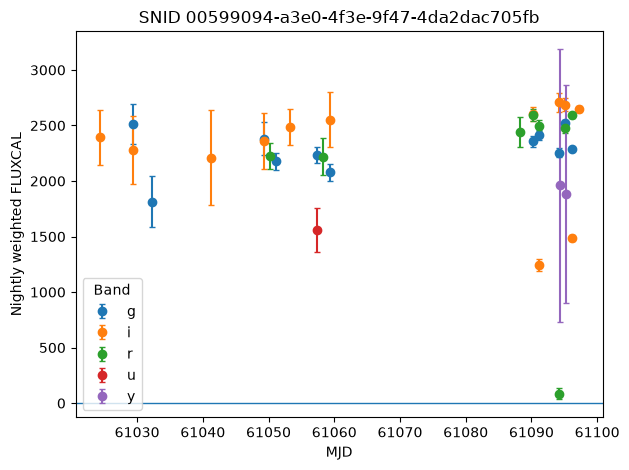

In [48]:
import numpy as np
import matplotlib.pyplot as plt

row = head_data[idx]
lc = phot_data[start:stop]

def make_nightly_lightcurve(lc):
    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(
        np.asarray(lc["BAND"]).astype(str)
    )
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    good = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & ((flag & 64) == 0)
        & (band != "-")
    )

    records = []

    for current_band in np.unique(band[good]):
        band_mask = good & (band == current_band)
        nights = np.floor(mjd[band_mask]).astype(int)

        for night in np.unique(nights):
            mask = band_mask & (
                np.floor(mjd).astype(int) == night
            )

            weights = 1.0 / fluxerr[mask] ** 2

            weighted_mjd = (
                np.sum(weights * mjd[mask])
                / np.sum(weights)
            )
            weighted_flux = (
                np.sum(weights * flux[mask])
                / np.sum(weights)
            )
            weighted_error = np.sqrt(
                1.0 / np.sum(weights)
            )

            records.append(
                (
                    weighted_mjd,
                    current_band,
                    weighted_flux,
                    weighted_error,
                    int(np.sum(mask)),
                )
            )

    dtype = [
        ("MJD", float),
        ("BAND", "U10"),
        ("FLUX", float),
        ("FLUXERR", float),
        ("NEXP", int),
    ]

    return np.array(records, dtype=dtype)


nightly = make_nightly_lightcurve(lc)

for band in np.unique(nightly["BAND"]):
    mask = nightly["BAND"] == band

    plt.errorbar(
        nightly["MJD"][mask],
        nightly["FLUX"][mask],
        yerr=nightly["FLUXERR"][mask],
        fmt="o",
        capsize=2,
        label=band,
    )

plt.axhline(0, linewidth=1)
plt.xlabel("MJD")
plt.ylabel("Nightly weighted FLUXCAL")
plt.title(f"SNID {row['SNID']}")
plt.legend(title="Band")
plt.tight_layout()
plt.show()

In [64]:
idx = np.argmax(head_data["NOBS"])
#idx = head_data["NOBS"][3]
row = head_data[idx]


start = int(row["PTROBS_MIN"]) - 1
stop = int(row["PTROBS_MAX"])

lc = phot_data[start:stop]

In [65]:
nightly = make_nightly_lightcurve(lc)

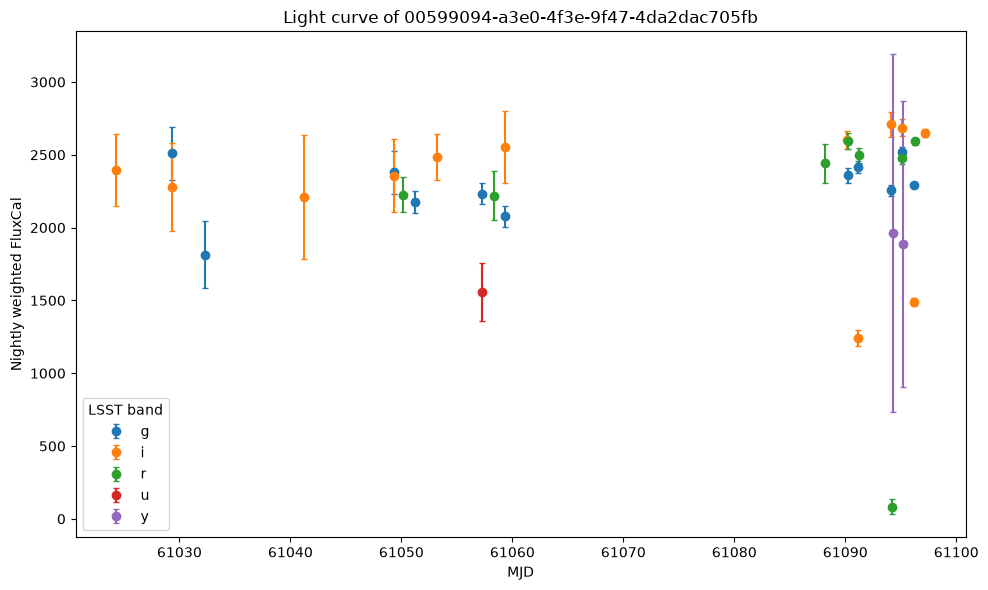

In [80]:
plt.figure(figsize=(10,6))

for band in np.unique(nightly["BAND"]):
    mask = nightly["BAND"] == band

    order = np.argsort(nightly["MJD"][mask])

  
    plt.errorbar(
        nightly["MJD"][mask][order],
        nightly["FLUX"][mask][order],
        yerr = nightly["FLUXERR"][mask][order],
        fmt = "o",
        capsize = 2,
        label = band
    )


#plt.axhline(0, linewidth = 1)
#colormap = plt.cm.viridis


plt.xlabel("MJD")
plt.ylabel("Nightly weighted FluxCal")
plt.title(f"Light curve of {row['SNID']}")
plt.legend(title = "LSST band")
plt.tight_layout()
plt.show()

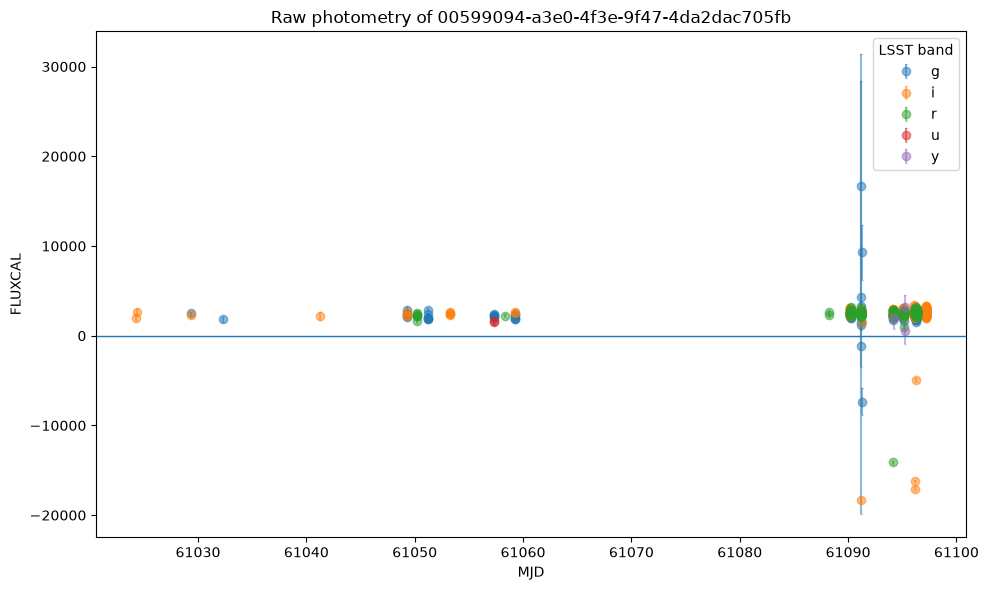

In [67]:
mjd = np.asarray(lc["MJD"], dtype=float)
band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
flux = np.asarray(lc["FLUXCAL"], dtype=float)
fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
flag = np.asarray(lc["PHOTFLAG"], dtype=int)

clean = (
    np.isfinite(mjd)
    & np.isfinite(flux)
    & np.isfinite(fluxerr)
    & (fluxerr > 0)
    & ((flag & 64) == 0)
    & (band != "-")
)

plt.figure(figsize=(10, 6))

for current_band in np.unique(band[clean]):
    mask = clean & (band == current_band)

    plt.errorbar(
        mjd[mask],
        flux[mask],
        yerr=fluxerr[mask],
        fmt="o",
        alpha=0.5,
        capsize=1,
        label=current_band,
    )

plt.axhline(0, linewidth=1)

plt.xlabel("MJD")
plt.ylabel("FLUXCAL")
plt.title(f"Raw photometry of {row['SNID']}")
plt.legend(title="LSST band")
plt.tight_layout()
plt.show()

In [81]:
#SED Plot 

target_mjd = 61095.0

for night in np.unique(np.floor(nightly["MJD"]).astype(int)):
    mask = np.floor(nightly["MJD"]).astype(int) == night

    available_bands = np.unique(nightly["BAND"][mask])

    print(
        night,
        "bands:",
        available_bands,
        "number of bands:",
        len(available_bands),
    )

61024 bands: ['i'] number of bands: 1
61029 bands: ['g' 'i'] number of bands: 2
61032 bands: ['g'] number of bands: 1
61041 bands: ['i'] number of bands: 1
61049 bands: ['g' 'i'] number of bands: 2
61050 bands: ['r'] number of bands: 1
61051 bands: ['g'] number of bands: 1
61053 bands: ['i'] number of bands: 1
61057 bands: ['g' 'u'] number of bands: 2
61058 bands: ['r'] number of bands: 1
61059 bands: ['g' 'i'] number of bands: 2
61088 bands: ['r'] number of bands: 1
61090 bands: ['g' 'i' 'r'] number of bands: 3
61091 bands: ['g' 'i' 'r'] number of bands: 3
61094 bands: ['g' 'i' 'r' 'y'] number of bands: 4
61095 bands: ['g' 'i' 'r' 'y'] number of bands: 4
61096 bands: ['g' 'i' 'r'] number of bands: 3
61097 bands: ['i'] number of bands: 1


In [82]:
effective_wavelength = {
    "u": 3670,
    "g": 4825,
    "r": 6222,
    "i": 7545,
    "z": 8691,
    "y": 9712,
}

def plot_broadband_sed(nightly, target_mjd, window=0.6):
    effective_wavelength = {
        "u": 3670,
        "g": 4825,
        "r": 6222,
        "i": 7545,
        "z": 8691,
        "y": 9712,
    }

    sed_rows = []

    for band_name in np.unique(nightly["BAND"]):
        if band_name not in effective_wavelength:
            continue

        mask = (
            (nightly["BAND"] == band_name)
            & (np.abs(nightly["MJD"] - target_mjd) <= window)
        )

        if not np.any(mask):
            continue

        # Select the nightly point closest to the requested time.
        candidate_indices = np.where(mask)[0]

        closest = candidate_indices[
            np.argmin(
                np.abs(
                    nightly["MJD"][candidate_indices]
                    - target_mjd
                )
            )
        ]

        sed_rows.append(
            (
                effective_wavelength[band_name],
                nightly["FLUX"][closest],
                nightly["FLUXERR"][closest],
                band_name,
                nightly["MJD"][closest],
            )
        )

    if len(sed_rows) == 0:
        raise ValueError(
            "No bands were observed close to the chosen MJD."
        )

    sed_rows.sort(key=lambda value: value[0])

    wavelength = np.array([x[0] for x in sed_rows])
    sed_flux = np.array([x[1] for x in sed_rows])
    sed_error = np.array([x[2] for x in sed_rows])
    sed_band = [x[3] for x in sed_rows]
    sed_mjd = np.array([x[4] for x in sed_rows])

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        wavelength,
        sed_flux,
        yerr=sed_error,
        fmt="o-",
        capsize=3,
    )

    for x, y, label in zip(
        wavelength,
        sed_flux,
        sed_band,
    ):
        plt.annotate(
            label,
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
        )

    plt.axhline(0, linewidth=1)

    plt.xlabel("Approximate observer-frame wavelength [Å]")
    plt.ylabel("FLUXCAL")
    plt.title(f"Broadband SED near MJD {target_mjd:.1f}")
    plt.tight_layout()
    plt.show()

    for label, measurement_mjd in zip(sed_band, sed_mjd):
        print(
            f"{label}: measurement from MJD "
            f"{measurement_mjd:.4f}"
        )

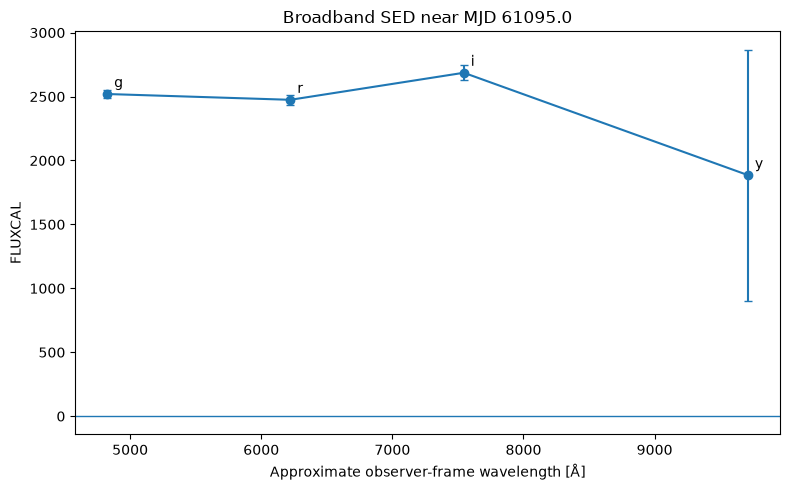

g: measurement from MJD 61095.1328
r: measurement from MJD 61095.1437
i: measurement from MJD 61095.1230
y: measurement from MJD 61095.2210


In [84]:
plot_broadband_sed(nightly, target_mjd = 61095.0, window = 6)

### Further inspection

In [85]:
for column in ["SNTYPE", "FAKE", "SEARCH_TYPE"]:
    values, counts = np.unique(
        head_data[column],
        return_counts=True,
    )

    print(f"\n{column}")
    for value, count in zip(values, counts):
        print(value, count)


SNTYPE
0 51000

FAKE
0 51000

SEARCH_TYPE
-9 50999
0 1


In [92]:
for column in [
    "PEAKMJD",
    "MJD_TRIGGER",
    "MJD_DETECT_FIRST",
    "MJD_DETECT_LAST",
]:
    values = np.asarray(head_data[column], dtype=float)

    print(
        "\n", column,
        "min =", np.min(values),
        "median =", np.median(values),
        "max =", np.max(values),
        #"missing =", np.sum(values <= -900),
        "missing =", np.sum(values < 10000)
    )


 PEAKMJD min = -9.0 median = 0.009999999776482582 max = 61235.4140625 missing = 45135

 MJD_TRIGGER min = -9.0 median = -9.0 max = 0.0 missing = 51000

 MJD_DETECT_FIRST min = 60973.16796875 median = 61218.296875 max = 61235.41796875 missing = 0

 MJD_DETECT_LAST min = 61088.09765625 median = 61230.265625 max = 61235.41796875 missing = 0


In [87]:
import pandas as pd
import numpy as np

def summarise_object(row, phot_data):
    start = int(row["PTROBS_MIN"]) - 1
    stop = int(row["PTROBS_MAX"])
    lc = phot_data[start:stop]

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    clean = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & ((flag & 64) == 0)
        & (band != "-")
    )

    detection = clean & ((flag & 1) != 0)

    clean_mjd = mjd[clean]
    clean_band = band[clean]

    return {
        "SNID": str(row["SNID"]),
        "SNTYPE": int(row["SNTYPE"]),
        "NOBS": int(row["NOBS"]),
        "N_CLEAN": int(np.sum(clean)),
        "N_DETECT": int(np.sum(detection)),
        "N_BANDS": int(len(np.unique(clean_band))),
        "N_NIGHTS": int(
            len(np.unique(np.floor(clean_mjd)))
            if len(clean_mjd) else 0
        ),
        "TIME_SPAN": float(
            np.ptp(clean_mjd)
            if len(clean_mjd) > 1 else 0
        ),
        "HAS_REDSHIFT": bool(
            np.isfinite(row["REDSHIFT_FINAL"])
            and row["REDSHIFT_FINAL"] > 0
        ),
    }

In [88]:
summary = pd.DataFrame(
    summarise_object(row, phot_data)
    for row in head_data[:1000]
)

summary.head()

,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT
0,00000533-33a2-42cf-bfa4-e4951522102f,0,2,2,2,1,2,4.0419,False
1,00001b7e-822c-4030-9b16-cf9cdca02319,0,2,2,2,1,2,30.9735,False
2,00001dd3-dcbc-436f-99d8-5f310e2212ba,0,2,2,2,1,2,10.0075,False
3,00004f91-a3cc-4f46-912b-df70ebb4c131,0,2,2,2,1,2,11.9482,False
4,00005c75-321d-47a7-ad59-9abf192e251b,0,2,2,2,1,2,8.0208,False


Not currently a ready-to-use Type Ia supernova sample. All 51,000 objects have `SNTYPE = 0`, `FAKE = 0`, and most have `SEARCH_TYPE = -9`, so no useful classification is provided. All redshift fields are set to `-999`. `MJD_TRIGGER` is missing for every object, with values of `-9` or `0`. `PEAKMJD` is missing or a placeholder for 45,135/51,000 objects, leaving only 5,865 objects with a plausible value above 10,000.`MJD_DETECT_FIRST` and `MJD_DETECT_LAST` contain valid dates for all objects. Most light curves are extremely sparse, with a median of only two observations. 

need to determine whether classifications and redshifts exist in another file or catalogue and identify the small subset of objects with sufficient temporal and multi-band coverage.


### Cutting and cleaning 

In [114]:
# Summary table 

def summarise_object(row, phot_data):
    start = int(row["PTROBS_MIN"]) - 1
    stop = int(row["PTROBS_MAX"])
    lc = phot_data[start:stop]

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    clean = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & ((flag & 64) == 0)
        & (band != "-")
    )

    detection = clean & ((flag & 1) != 0)

    clean_mjd = mjd[clean]
    clean_band = band[clean]

    return {
        "SNID": clean_snid(row["SNID"]),
        "SNTYPE": int(row["SNTYPE"]),
        "NOBS": int(row["NOBS"]),
        "N_CLEAN": int(np.sum(clean)),
        "N_DETECT": int(np.sum(detection)),
        "N_BANDS": int(len(np.unique(clean_band))),
        "N_NIGHTS": int(
            len(np.unique(np.floor(clean_mjd)))
            if len(clean_mjd) else 0
        ),
        "TIME_SPAN": float(
            np.ptp(clean_mjd)
            if len(clean_mjd) > 1 else 0
        ),
        "HAS_REDSHIFT": bool(
            np.isfinite(row["REDSHIFT_FINAL"])
            and row["REDSHIFT_FINAL"] > 0
        ),
    }

In [115]:
summary.sort_values(
    ["N_NIGHTS", "N_BANDS", "TIME_SPAN"],
    ascending=False,
).head(20)

,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT
152,00143d0c-fe4a-4ab3-ab88-6ad47acd757a,0,108,108,59,6,47,155.6719,False
391,003351c8-54e3-4c9d-bd30-75d182ca79eb,0,102,102,38,6,39,114.7809,False
890,0075e4a4-4237-4d2b-bed5-3b1715a424bf,0,94,94,18,6,37,114.7763,False
922,0078f7fe-eedb-42f4-9b56-13b892c8809c,0,88,88,28,6,34,151.6609,False
667,00599094-a3e0-4f3e-9f47-4da2dac705fb,0,756,609,584,5,18,72.9868,False
533,0046d02c-7800-475c-9faf-42ec4b5819e4,0,35,35,32,6,14,64.8310,False
953,007ce09f-bb55-4559-abb7-7c318758fc48,0,28,28,21,4,13,184.2951,False
784,0068d229-0b49-4dae-9d47-4e6d8caa3e5e,0,36,36,18,5,11,16.8751,False
362,0030b2e5-7af6-4ca1-a508-ebfb894064e0,0,29,29,12,4,11,12.0471,False
722,0061c7e5-8c61-411f-b223-651af023f327,0,24,24,15,5,10,66.8054,False


In [116]:
candidates = summary.sort_values(
    ["N_NIGHTS", "N_BANDS", "TIME_SPAN", "N_DETECT"],
    ascending=False,
)

candidates.head(20)

,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT
152,00143d0c-fe4a-4ab3-ab88-6ad47acd757a,0,108,108,59,6,47,155.6719,False
391,003351c8-54e3-4c9d-bd30-75d182ca79eb,0,102,102,38,6,39,114.7809,False
890,0075e4a4-4237-4d2b-bed5-3b1715a424bf,0,94,94,18,6,37,114.7763,False
922,0078f7fe-eedb-42f4-9b56-13b892c8809c,0,88,88,28,6,34,151.6609,False
667,00599094-a3e0-4f3e-9f47-4da2dac705fb,0,756,609,584,5,18,72.9868,False
533,0046d02c-7800-475c-9faf-42ec4b5819e4,0,35,35,32,6,14,64.8310,False
953,007ce09f-bb55-4559-abb7-7c318758fc48,0,28,28,21,4,13,184.2951,False
784,0068d229-0b49-4dae-9d47-4e6d8caa3e5e,0,36,36,18,5,11,16.8751,False
362,0030b2e5-7af6-4ca1-a508-ebfb894064e0,0,29,29,12,4,11,12.0471,False
722,0061c7e5-8c61-411f-b223-651af023f327,0,24,24,15,5,10,66.8054,False


In [118]:
candidates.iloc[0]["SNID"]


'00143d0c-fe4a-4ab3-ab88-6ad47acd757a'

In [112]:
def clean_snid(value):
    if isinstance(value, bytes):
        return value.decode("utf-8").strip()
    return str(value).strip()

In [113]:
candidate_snid = clean_snid(candidates.iloc[0]["SNID"])

head_snids = np.array(
    [clean_snid(value) for value in head_data["SNID"]]
)

matches = np.where(head_snids == candidate_snid)[0]

print("Candidate SNID:", repr(candidate_snid))
print("Number of matches:", len(matches))
print("Matches:", matches)

Candidate SNID: '00143d0c-fe4a-4ab3-ab88-6ad47acd757a'
Number of matches: 1
Matches: [152]


In [125]:
if len(matches) == 0:
    raise ValueError(
        f"SNID {candidate_snid!r} was not found in head_data."
    )

if len(matches) > 1:
    raise ValueError(
        f"SNID {candidate_snid!r} occurs {len(matches)} times."
    )

idx = matches[0]
row = head_data[idx]

start = int(row["PTROBS_MIN"]) - 1
stop = int(row["PTROBS_MAX"])

lc = phot_data[start:stop]

print("HEAD index:", idx)
print("Expected observations:", int(row["NOBS"]))
print("Extracted observations:", len(lc))

HEAD index: 152
Expected observations: 108
Extracted observations: 108


In [127]:
nightly = make_nightly_lightcurve(lc)

In [ ]:
for rank in range(5):
    candidate_snid = candidates.iloc[rank]["SNID"]

    matches = np.where(
        np.asarray(head_data["SNID"]).astype(str)
        == candidate_snid
    )[0]

    print(
        rank,
        candidate_snid,
        "matches:",
        len(matches),
    )

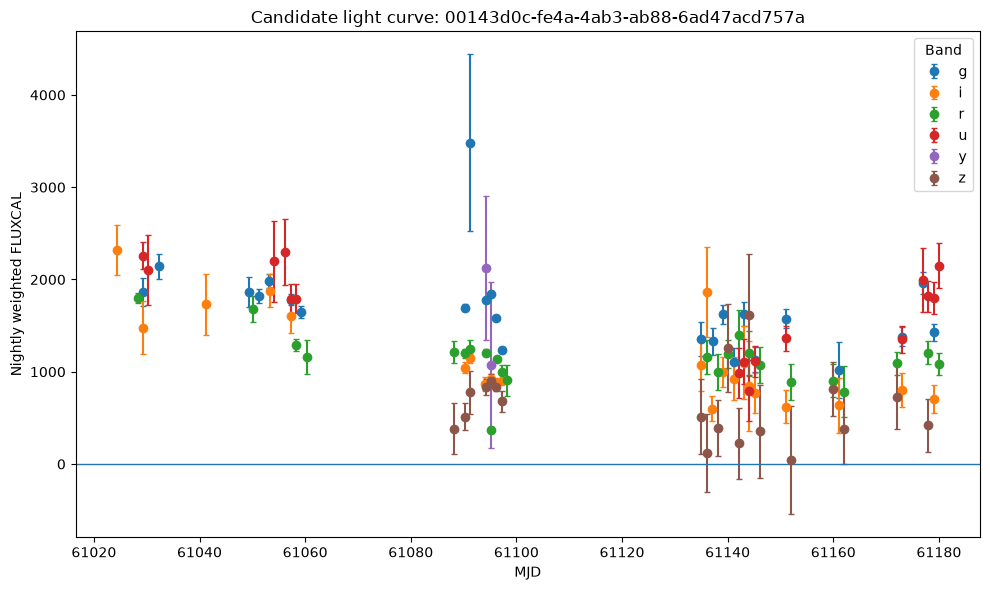

In [130]:
# Plotting best candiidat 

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for current_band in np.unique(nightly["BAND"]):
    mask = nightly["BAND"] == current_band

    order = np.argsort(nightly["MJD"][mask])

    plt.errorbar(
        nightly["MJD"][mask][order],
        nightly["FLUX"][mask][order],
        yerr=nightly["FLUXERR"][mask][order],
        fmt="o",
        capsize=2,
        label=current_band,
    )

plt.axhline(0, linewidth=1)

plt.xlabel("MJD")
plt.ylabel("Nightly weighted FLUXCAL")
plt.title(f"Candidate light curve: {clean_snid(row['SNID'])}")
plt.legend(title="Band")
plt.tight_layout()
plt.show()

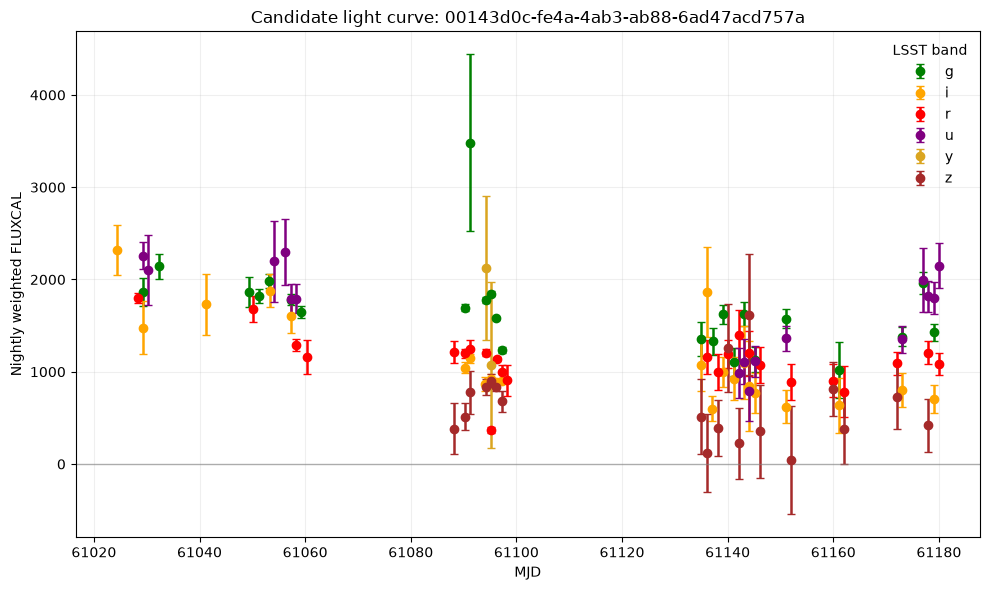

In [133]:
band_colours = {
    "u": "purple",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "brown",
    "y": "goldenrod",
}


plt.figure(figsize=(10, 6))

for current_band in np.unique(nightly["BAND"]):
    mask = nightly["BAND"] == current_band
    order = np.argsort(nightly["MJD"][mask])

    plt.errorbar(
        nightly["MJD"][mask][order],
        nightly["FLUX"][mask][order],
        yerr=nightly["FLUXERR"][mask][order],
        fmt="o",
        capsize=3,
        linewidth=1.8,
        markersize=6,
        color=band_colours.get(current_band, "black"),
        label=current_band,
    )

plt.axhline(0, linewidth=1, color="grey", alpha=0.6)
plt.xlabel("MJD")
plt.ylabel("Nightly weighted FLUXCAL")
plt.title(f"Candidate light curve: {clean_snid(row['SNID'])}")
plt.legend(title="LSST band", frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()